# Finite Difference Method for 1D Heat Conduction

## Explicit & Implicit Schemes, TDMA, Stability & Convergence

This notebook implements the FDM for the 1D transient heat equation

$$
\frac{\partial T}{\partial t} = \alpha \frac{\partial^2 T}{\partial x^2}
$$

| Scheme | Update | Stability | Matrix |
|--------|--------|:---------:|--------|
| **Explicit** | $T_i^{n+1}$ from $T^n$ directly | $Fo \le 0.5$ | None (direct) |
| **Implicit** | Solve tridiagonal system | Unconditionally stable | Tridiagonal |
| **Crank–Nicolson** | Average of both | Unconditionally stable | Tridiagonal |

where the **Fourier number** $Fo = \alpha\,\Delta t / \Delta x^2$ controls accuracy and stability.

---

## 1 — Imports

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

## 2 — Discretisation & Stencils

The second derivative is approximated by the central difference:

$$
\frac{\partial^2 T}{\partial x^2}\bigg|_i
\approx \frac{T_{i-1} - 2T_i + T_{i+1}}{\Delta x^2}
$$

### Explicit scheme

Evaluate the spatial derivative at the *current* time level $n$:

$$T_i^{n+1} = T_i^n + Fo\,(T_{i-1}^n - 2T_i^n + T_{i+1}^n)$$

### Implicit scheme

Evaluate at the *next* time level $n+1$ → must solve a system:

$$-Fo\,T_{i-1}^{n+1} + (1+2Fo)\,T_i^{n+1} - Fo\,T_{i+1}^{n+1} = T_i^n$$

This gives a **tridiagonal** matrix $[A]\{T^{n+1}\} = \{d\}$ with
coefficients $a = -Fo$, $b = 1+2Fo$, $c = -Fo$.

In [11]:
def tdma(a, b, c, d):
    """
    Thomas Algorithm (TDMA) for tridiagonal systems.
    Solves  a_i x_{i-1} + b_i x_i + c_i x_{i+1} = d_i.
    O(N) complexity.
    """
    n = len(d)
    cp = np.zeros(n)
    dp = np.zeros(n)
    x  = np.zeros(n)

    # Forward sweep
    cp[0] = c[0] / b[0]
    dp[0] = d[0] / b[0]
    for i in range(1, n):
        m = b[i] - a[i] * cp[i-1]
        cp[i] = c[i] / m if i < n-1 else 0
        dp[i] = (d[i] - a[i] * dp[i-1]) / m

    # Back substitution
    x[-1] = dp[-1]
    for i in range(n-2, -1, -1):
        x[i] = dp[i] - cp[i] * x[i+1]
    return x

In [12]:
def fdm_explicit(N, L, alpha, dt, T_init, T_left, T_right, n_steps):
    """Explicit (forward) Euler FDM for 1D heat equation."""
    dx = L / (N - 1)
    Fo = alpha * dt / dx**2
    x  = np.linspace(0, L, N)
    T  = np.full(N, T_init)
    T[0] = T_left; T[-1] = T_right

    history = [T.copy()]
    for _ in range(n_steps):
        T_new = T.copy()
        for i in range(1, N-1):
            T_new[i] = T[i] + Fo * (T[i-1] - 2*T[i] + T[i+1])
        T_new[0] = T_left; T_new[-1] = T_right
        T = T_new
        history.append(T.copy())
    return x, np.array(history), Fo


def fdm_implicit(N, L, alpha, dt, T_init, T_left, T_right, n_steps,
                 conductivity=10.0, bc_left=None, bc_right=None):
    """
    Implicit (backward) Euler FDM for 1D heat equation.
    Supports Dirichlet and convective BCs.
    Solved with TDMA.
    """
    dx = L / (N - 1)
    Fo = alpha * dt / dx**2
    x  = np.linspace(0, L, N)
    T  = np.full(N, T_init)

    if bc_left is None:
        bc_left = {"type": "fixed", "val": T_left}
    if bc_right is None:
        bc_right = {"type": "fixed", "val": T_right}

    # Apply initial BCs
    if bc_left["type"] == "fixed": T[0] = bc_left["val"]
    if bc_right["type"] == "fixed": T[-1] = bc_right["val"]

    history = [T.copy()]
    for _ in range(n_steps):
        aa = np.zeros(N); bb = np.zeros(N)
        cc = np.zeros(N); dd = np.zeros(N)

        # Interior nodes
        for i in range(1, N-1):
            aa[i] = -Fo
            bb[i] = 1 + 2*Fo
            cc[i] = -Fo
            dd[i] = T[i]

        # Left BC
        if bc_left["type"] == "fixed":
            bb[0] = 1; cc[0] = 0; dd[0] = bc_left["val"]
        else:  # convection
            Bi = bc_left["h"] * dx / conductivity
            bb[0] = 1 + Bi; cc[0] = -1; dd[0] = Bi * bc_left["tInf"]

        # Right BC
        if bc_right["type"] == "fixed":
            aa[-1] = 0; bb[-1] = 1; dd[-1] = bc_right["val"]
        else:
            Bi = bc_right["h"] * dx / conductivity
            aa[-1] = -1; bb[-1] = 1 + Bi; dd[-1] = Bi * bc_right["tInf"]

        T = tdma(aa, bb, cc, dd)
        history.append(T.copy())
    return x, np.array(history), Fo


def fdm_crank_nicolson(N, L, alpha, dt, T_init, T_left, T_right, n_steps):
    """Crank-Nicolson (average of explicit + implicit)."""
    dx = L / (N - 1)
    Fo = alpha * dt / dx**2
    x  = np.linspace(0, L, N)
    T  = np.full(N, T_init)
    T[0] = T_left; T[-1] = T_right

    history = [T.copy()]
    for _ in range(n_steps):
        aa = np.zeros(N); bb = np.zeros(N)
        cc = np.zeros(N); dd = np.zeros(N)

        for i in range(1, N-1):
            aa[i] = -Fo/2
            bb[i] = 1 + Fo
            cc[i] = -Fo/2
            # RHS includes explicit part
            dd[i] = (Fo/2)*T[i-1] + (1-Fo)*T[i] + (Fo/2)*T[i+1]

        bb[0] = 1; dd[0] = T_left
        bb[-1] = 1; dd[-1] = T_right

        T = tdma(aa, bb, cc, dd)
        history.append(T.copy())
    return x, np.array(history), Fo

## 3 — Basic Example: Cooling of a Hot Rod

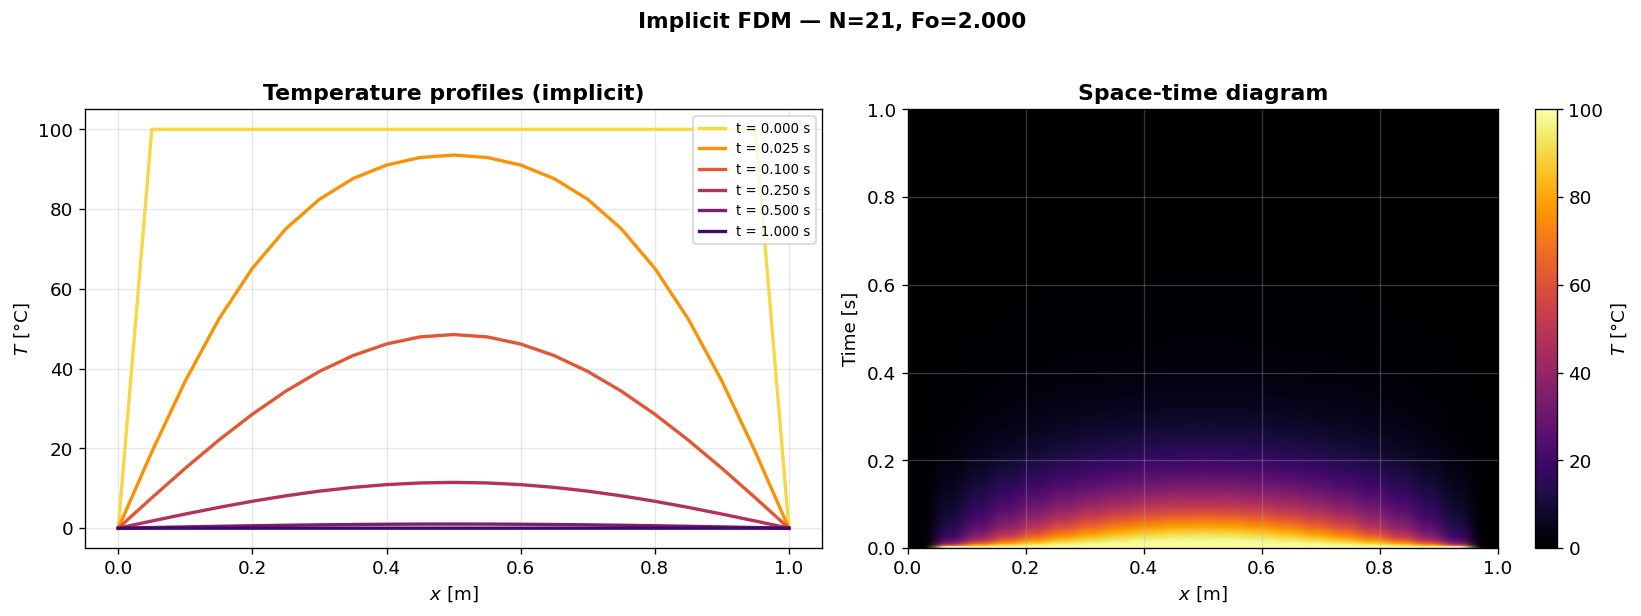

Fourier number Fo = 2.0000
Δx = 0.0500 m,  Δt = 0.005 s


In [13]:
# Parameters
N       = 21       # nodes
L       = 1.0      # length [m]
alpha   = 1.0      # diffusivity [m²/s]
dt      = 0.005    # time step [s]
T_init  = 100.0    # initial temp [°C]
T_left  = 0.0      # left BC
T_right = 0.0      # right BC
n_steps = 200

x, hist_impl, Fo = fdm_implicit(N, L, alpha, dt, T_init, T_left, T_right, n_steps)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: temperature profiles at selected times
times_to_plot = [0, 5, 20, 50, 100, 200]
cmap_vals = plt.cm.inferno(np.linspace(0.9, 0.2, len(times_to_plot)))
for step, col in zip(times_to_plot, cmap_vals):
    ax1.plot(x, hist_impl[step], color=col, lw=2,
             label=f"t = {step*dt:.3f} s")
ax1.set_xlabel("$x$ [m]")
ax1.set_ylabel("$T$ [°C]")
ax1.set_title("Temperature profiles (implicit)", fontweight="bold")
ax1.legend(fontsize=8)

# Right: space-time heatmap
im = ax2.imshow(hist_impl, aspect="auto", origin="lower",
                extent=[0, L, 0, n_steps*dt], cmap="inferno")
fig.colorbar(im, ax=ax2, label="$T$ [°C]")
ax2.set_xlabel("$x$ [m]")
ax2.set_ylabel("Time [s]")
ax2.set_title("Space-time diagram", fontweight="bold")

fig.suptitle(f"Implicit FDM — N={N}, Fo={Fo:.3f}",
             fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

print(f"Fourier number Fo = {Fo:.4f}")
print(f"Δx = {L/(N-1):.4f} m,  Δt = {dt} s")

## 4 — Explicit vs. Implicit: Stability

The explicit scheme requires $Fo \le 0.5$ or it **blows up**.
The implicit scheme is unconditionally stable.

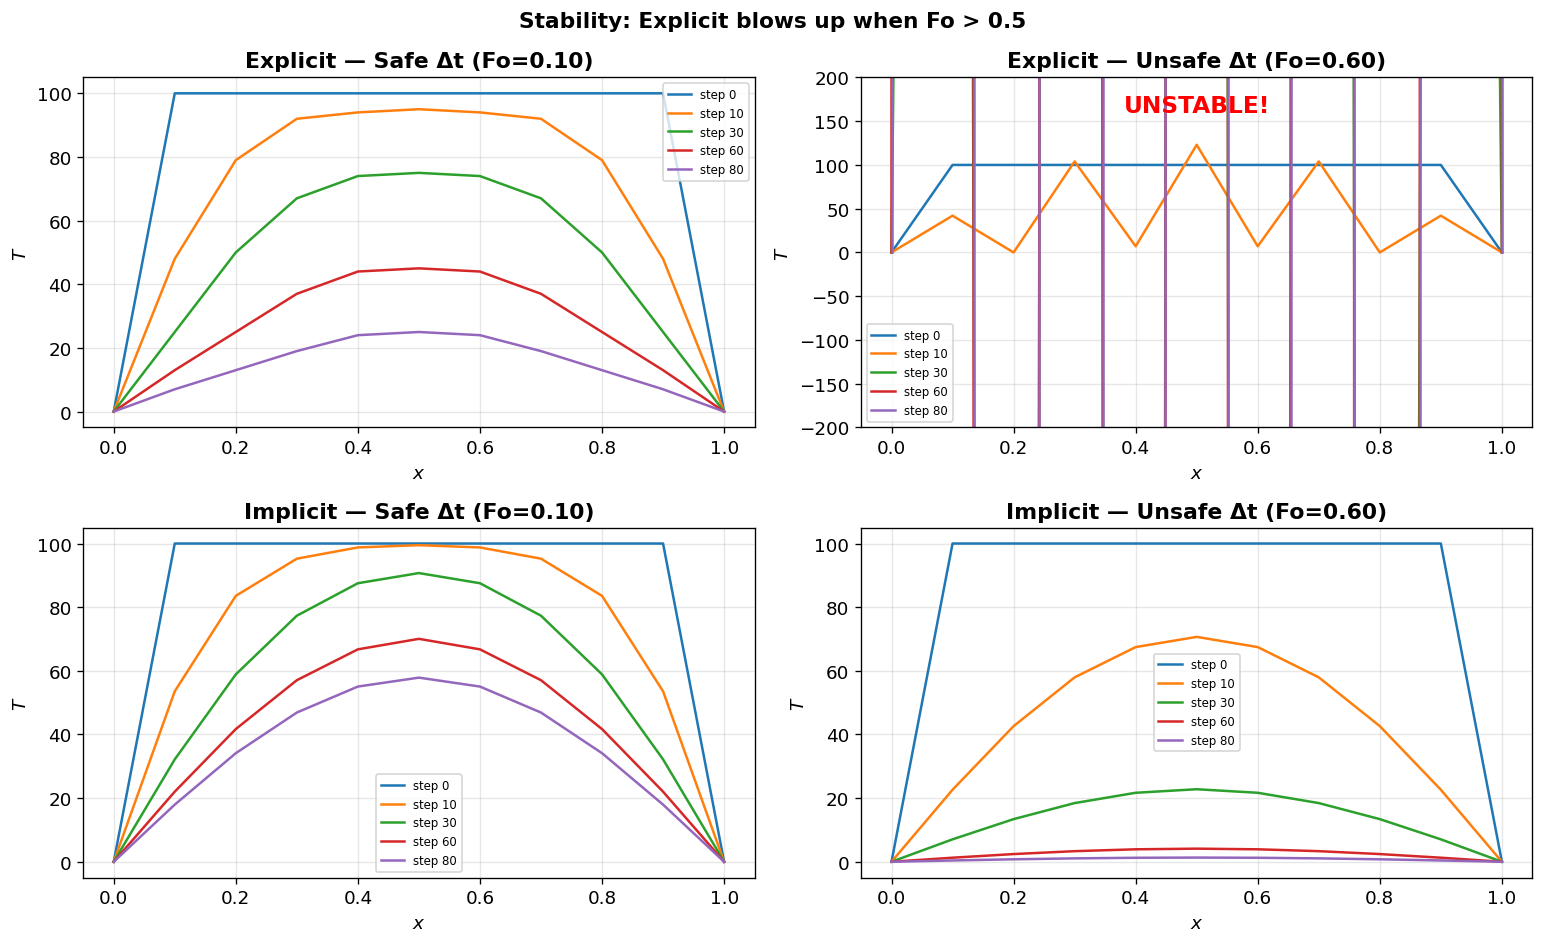

In [14]:
N = 11
dt_safe   = 0.001   # Fo ≈ 0.1  (stable)
dt_unsafe = 0.006   # Fo ≈ 0.6  (UNSTABLE for explicit)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for col_idx, (dt_val, label) in enumerate(
    [(dt_safe, "Safe Δt"), (dt_unsafe, "Unsafe Δt")]):
    
    # Explicit
    x, hist_e, Fo_e = fdm_explicit(N, 1.0, 1.0, dt_val, 100, 0, 0, 80)
    ax = axes[0, col_idx]
    for step in [0, 10, 30, 60, 80]:
        if step < len(hist_e):
            ax.plot(x, hist_e[step], lw=1.5, label=f"step {step}")
    ax.set_title(f"Explicit — {label} (Fo={Fo_e:.2f})", fontweight="bold")
    ax.set_xlabel("$x$"); ax.set_ylabel("$T$")
    if Fo_e > 0.5:
        ax.set_ylim(-200, 200)
        ax.text(0.5, 0.9, "UNSTABLE!", transform=ax.transAxes, fontsize=14,
                color="red", fontweight="bold", ha="center")
    ax.legend(fontsize=7)

    # Implicit
    x, hist_i, Fo_i = fdm_implicit(N, 1.0, 1.0, dt_val, 100, 0, 0, 80)
    ax = axes[1, col_idx]
    for step in [0, 10, 30, 60, 80]:
        ax.plot(x, hist_i[step], lw=1.5, label=f"step {step}")
    ax.set_title(f"Implicit — {label} (Fo={Fo_i:.2f})", fontweight="bold")
    ax.set_xlabel("$x$"); ax.set_ylabel("$T$")
    ax.legend(fontsize=7)

fig.suptitle("Stability: Explicit blows up when Fo > 0.5",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

## 5 — The Tridiagonal Matrix

The implicit scheme produces a **tridiagonal** matrix — only three
diagonals are nonzero. This is solved in $O(N)$ by the **Thomas
Algorithm (TDMA)** instead of $O(N^3)$ for a general solver.

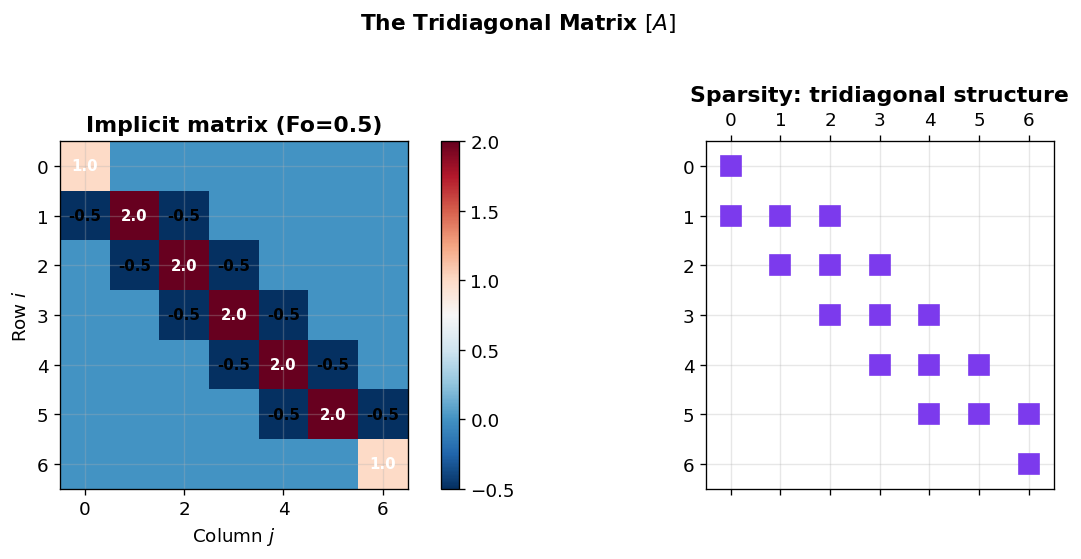

Matrix size: 7×7 = 49 entries
Nonzeros: 17  (35% fill)
TDMA cost: O(7)  vs  LU: O(7³) = O(343)


In [15]:
N = 7; Fo = 0.5

# Build the implicit matrix for visualisation
A = np.zeros((N, N))
for i in range(1, N-1):
    A[i, i-1] = -Fo
    A[i, i]   = 1 + 2*Fo
    A[i, i+1] = -Fo
A[0, 0] = 1          # left BC (Dirichlet)
A[-1, -1] = 1        # right BC (Dirichlet)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Matrix values
im = ax1.imshow(A, cmap="RdBu_r", vmin=-Fo, vmax=1+2*Fo)
fig.colorbar(im, ax=ax1)
for i in range(N):
    for j in range(N):
        val = A[i, j]
        if abs(val) > 0.01:
            ax1.text(j, i, f"{val:.1f}", ha="center", va="center",
                     fontsize=9, fontweight="bold",
                     color="w" if abs(val) > Fo else "k")
ax1.set_title(f"Implicit matrix (Fo={Fo})", fontweight="bold")
ax1.set_xlabel("Column $j$"); ax1.set_ylabel("Row $i$")

# Sparsity pattern
ax2.spy(A, markersize=12, color="#7c3aed")
ax2.set_title("Sparsity: tridiagonal structure", fontweight="bold")

fig.suptitle("The Tridiagonal Matrix $[A]$",
             fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

nnz = np.count_nonzero(A)
print(f"Matrix size: {N}×{N} = {N*N} entries")
print(f"Nonzeros: {nnz}  ({100*nnz/N**2:.0f}% fill)")
print(f"TDMA cost: O({N})  vs  LU: O({N}³) = O({N**3})")

## 6 — Three Schemes Compared

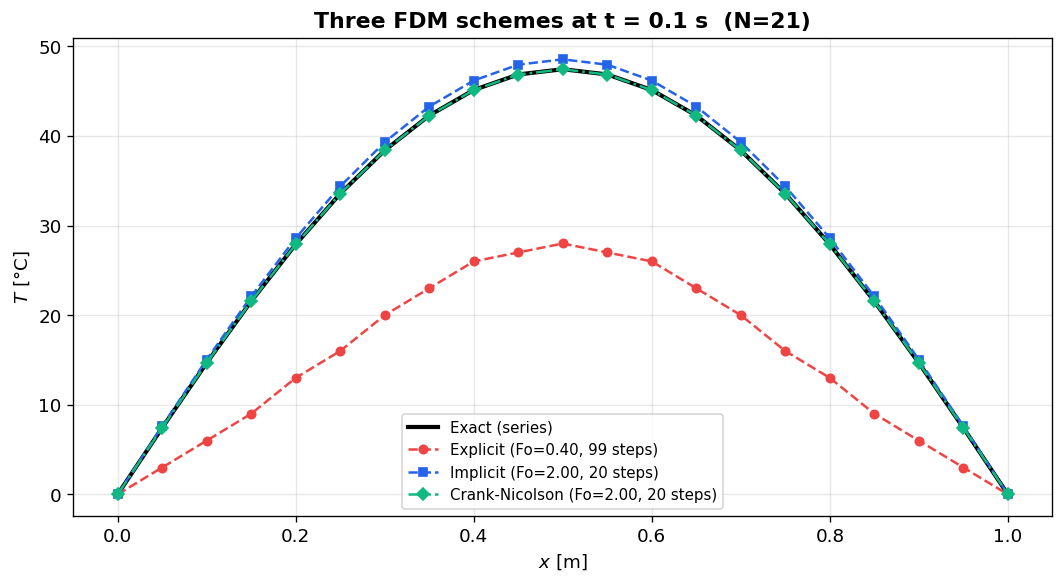

Time steps to reach t = 0.1 s:
  Explicit         Fo=0.40  Δt=0.00100  steps=  99  max error=1.9865e+01
  Implicit         Fo=2.00  Δt=0.00500  steps=  20  max error=1.1020e+00
  Crank-Nicolson   Fo=2.00  Δt=0.00500  steps=  20  max error=1.0953e-02

→ Explicit needs MANY more steps to stay stable!
  Implicit and C-N can take large steps without blowing up.


In [16]:
N = 21
dx = 1.0 / (N - 1)
t_final = 0.1          # compare at this physical time

# Explicit needs a SAFE time step (Fo ≤ 0.5)
dt_explicit = 0.4 * dx**2 / 1.0    # Fo = 0.4 (safe)
n_explicit  = int(t_final / dt_explicit)

# Implicit and C-N can use much larger steps
dt_implicit = 0.005                 # Fo = 2.0 (fine for implicit)
n_implicit  = int(t_final / dt_implicit)

x_e, h_e, Fo_e = fdm_explicit(N, 1.0, 1.0, dt_explicit, 100, 0, 0, n_explicit)
x_i, h_i, Fo_i = fdm_implicit(N, 1.0, 1.0, dt_implicit, 100, 0, 0, n_implicit)
x_c, h_c, Fo_c = fdm_crank_nicolson(N, 1.0, 1.0, dt_implicit, 100, 0, 0, n_implicit)

# Analytical solution
def exact_solution(x, t, L=1.0, T0=100, n_terms=50):
    T = np.zeros_like(x)
    for n in range(1, n_terms+1, 2):   # odd terms only
        T += (4*T0/(n*np.pi)) * np.sin(n*np.pi*x/L) * np.exp(-(n*np.pi/L)**2 * t)
    return T

T_exact = exact_solution(x_e, t_final)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x_e, T_exact, "k-", lw=2.5, label="Exact (series)")
ax.plot(x_e, h_e[-1], "o--", color="#ef4444", lw=1.5, markersize=5,
        label=f"Explicit (Fo={Fo_e:.2f}, {n_explicit} steps)")
ax.plot(x_i, h_i[-1], "s--", color="#2563eb", lw=1.5, markersize=5,
        label=f"Implicit (Fo={Fo_i:.2f}, {n_implicit} steps)")
ax.plot(x_c, h_c[-1], "D-.", color="#10b981", lw=1.5, markersize=5,
        label=f"Crank-Nicolson (Fo={Fo_c:.2f}, {n_implicit} steps)")

ax.set_xlabel("$x$ [m]")
ax.set_ylabel("$T$ [°C]")
ax.set_title(f"Three FDM schemes at t = {t_final} s  (N={N})",
             fontweight="bold")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

# Error comparison
print(f"Time steps to reach t = {t_final} s:")
for name, hist, n_st, dt_used, Fo_val in [
    ("Explicit",       h_e, n_explicit, dt_explicit, Fo_e),
    ("Implicit",       h_i, n_implicit, dt_implicit, Fo_i),
    ("Crank-Nicolson", h_c, n_implicit, dt_implicit, Fo_c),
]:
    err = np.max(np.abs(hist[-1] - T_exact))
    print(f"  {name:<16} Fo={Fo_val:.2f}  Δt={dt_used:.5f}  "
          f"steps={n_st:>4}  max error={err:.4e}")
print()
print("→ Explicit needs MANY more steps to stay stable!")
print("  Implicit and C-N can take large steps without blowing up.")


## 7 — Convective Boundary Conditions

At a convective boundary:
$-k\frac{dT}{dx}\big|_{x=0} = h(T_0 - T_\infty)$

Discretised: $(1 + Bi)\,T_0 - T_1 = Bi\cdot T_\infty$

where the **Biot number** $Bi = h\,\Delta x / k$.

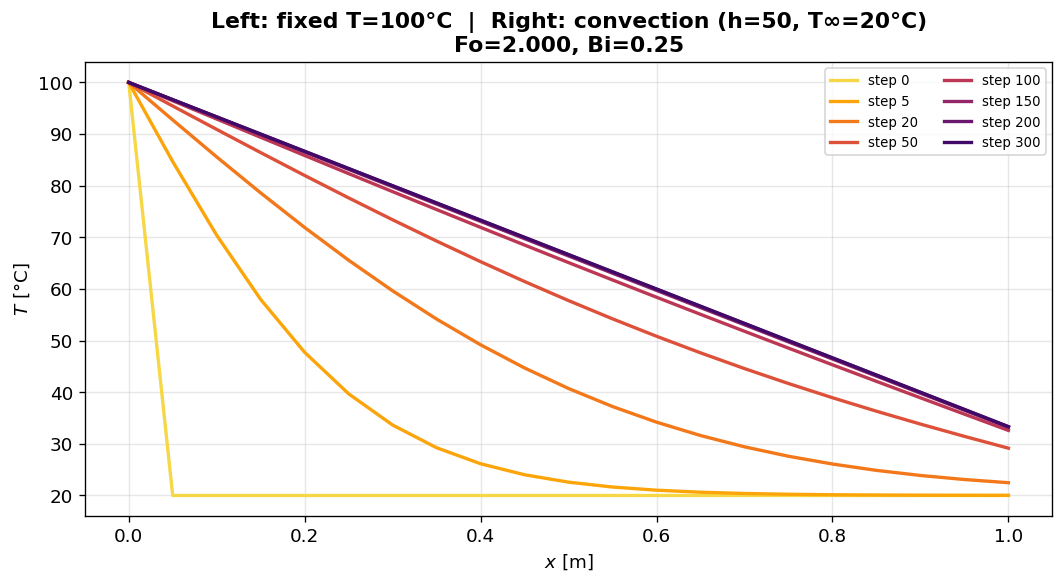

In [17]:
N = 21; n_steps = 300

bc_left  = {"type": "fixed", "val": 100}
bc_right = {"type": "convection", "h": 50, "tInf": 20}

x, hist, Fo = fdm_implicit(N, 1.0, 1.0, 0.005, 20, 100, 20, n_steps,
                            conductivity=10.0,
                            bc_left=bc_left, bc_right=bc_right)

Bi = bc_right["h"] * (1.0/(N-1)) / 10.0

fig, ax = plt.subplots(figsize=(9, 5))
cmap_vals = plt.cm.inferno(np.linspace(0.9, 0.2, 8))
for step, col in zip([0, 5, 20, 50, 100, 150, 200, 300], cmap_vals):
    ax.plot(x, hist[step], color=col, lw=2, label=f"step {step}")

ax.set_xlabel("$x$ [m]")
ax.set_ylabel("$T$ [°C]")
ax.set_title(
    f"Left: fixed T=100°C  |  Right: convection (h={bc_right['h']}, T∞={bc_right['tInf']}°C)\n"
    f"Fo={Fo:.3f}, Bi={Bi:.2f}",
    fontweight="bold",
)
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

## 8 — Grid Convergence Study

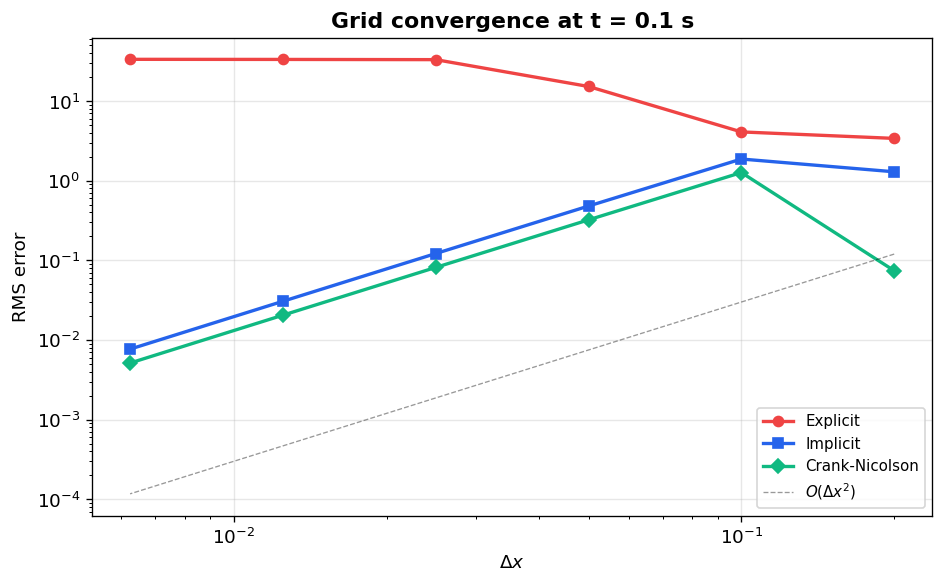

In [18]:
Ns = [6, 11, 21, 41, 81, 161]
t_target = 0.1

fig, ax = plt.subplots(figsize=(8, 5))

for scheme, solver, col, marker in [
    ("Explicit",       fdm_explicit,        "#ef4444", "o"),
    ("Implicit",       fdm_implicit,        "#2563eb", "s"),
    ("Crank-Nicolson", fdm_crank_nicolson,  "#10b981", "D"),
]:
    errors = []
    dxs = []
    for N in Ns:
        dx = 1.0 / (N-1)
        # Keep Fo safe for explicit
        dt_use = min(0.4 * dx**2, 0.01)
        n_steps = int(t_target / dt_use)
        x, hist, Fo = solver(N, 1.0, 1.0, dt_use, 100, 0, 0, n_steps)
        T_exact = exact_solution(x, t_target)
        err = np.sqrt(np.mean((hist[-1] - T_exact)**2))
        errors.append(err)
        dxs.append(dx)

    ax.loglog(dxs, errors, f"{marker}-", color=col, lw=2, markersize=6,
              label=scheme)

# Reference slopes
dx_ref = np.array(dxs)
ax.loglog(dx_ref, 3*dx_ref**2, "k--", lw=0.8, alpha=0.4, label="$O(\\Delta x^2)$")

ax.set_xlabel("$\\Delta x$")
ax.set_ylabel("RMS error")
ax.set_title(f"Grid convergence at t = {t_target} s", fontweight="bold")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

## 9 — Notes for Students

### Key take-aways

1. **FDM replaces derivatives with differences** — the second
   derivative becomes a 3-point stencil.

2. **Fourier number** $Fo = \alpha\Delta t/\Delta x^2$ controls
   everything: accuracy, stability, and the matrix coefficients.

3. **Explicit is simple but conditionally stable** ($Fo \le 0.5$).
   Implicit is unconditionally stable but requires solving a system.

4. **The tridiagonal structure** is the key efficiency gain.
   TDMA solves in $O(N)$ — this is what makes implicit FDM
   practical even for fine meshes.

5. **Crank–Nicolson** averages explicit and implicit, giving
   $O(\Delta t^2)$ temporal accuracy while remaining A-stable.

6. **Biot number** $Bi = h\Delta x/k$ controls convective BCs.
   It modifies the first/last row of the tridiagonal matrix.

### Exercises

1. Verify that the explicit scheme blows up at exactly $Fo = 0.5$
   by running with $Fo = 0.49, 0.50, 0.51$.

2. Implement a **heat source term** $\dot{q}$: add $\dot{q}\Delta t / (\rho c_p)$
   to the right-hand side vector.

3. Extend to **2D** on a rectangular grid. The matrix is no longer
   tridiagonal — it becomes **pentadiagonal** (or banded).

4. Compare TDMA's $O(N)$ runtime with `np.linalg.solve`'s $O(N^3)$
   by timing both for $N = 100, 1000, 10000$.

5. Implement an **adaptive time-stepping** scheme that picks
   $\Delta t$ to keep the maximum temperature change per step
   below a user-specified threshold.

---

*Notebook companion to the interactive React teaching app (FDM 1D Heat Conduction).*  
*TDMA solver implemented from scratch — no external libraries required.*